# AbruptInsects detector comparison inside STUDD

This notebook compares different drift detectors inside the STUDD mechanism on the AbruptInsects dataset.

AbruptInsects is a modified version of the Insects dataset where the stream is split into three segments and the middle segment is shuffled to introduce abrupt drift in the feature space.

The goal is to follow the alarm-analysis used in the STUDD paper, so we do not use the injected drift points as ground-truth drift points. Instead, we run a strongly supervised detector (SS) and use its first alarm as the reference drift point.

For each detector, we record:

- all alarms produced by the detector
- all SS alarms
- teacher accuracy around the first SS alarm (reference alarm)
- teacher-student disagreement around the first SS alarm
- teacher accuracy around the closest (to the reference) STUDD alarm
- teacher-student disagreement around the closest STUDD alarm




In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from capymoa.stream import NumpyStream

from capymoa.drift.detectors import (
    STUDD,
    ADWIN,
    PageHinkley,
    HDDMAverage,
    HDDMWeighted,
    CUSUM,
)

from helpers import (
    configure_matplotlib,
    rolling_mean,
)

from studd_utils import (
    make_teacher,
    make_student,
)

configure_matplotlib()

## Load AbruptInsects data

The dataset is stored as a comma-separated `.data` file.

The last column is the class label and all previous columns are input features.

In [3]:
DATA_PATH = "data/AbruptInsects.data"

df = pd.read_csv(
    DATA_PATH,
    header=None,
)

X = df.iloc[:, :-1].to_numpy(dtype=float)
y = df.iloc[:, -1].to_numpy(dtype=int)

print("Shape:", df.shape)
print("Class distribution:")
print(pd.Series(y).value_counts().sort_index())

Shape: (5325, 50)
Class distribution:
1     954
2     917
3    1265
4    1285
5     904
Name: count, dtype: int64


## Experimental parameters

The teacher is trained on the first `W` labeled samples.

During monitoring, the teacher remains fixed and the student learns to mimic the teacher.

The supervised signal detector (SS) monitors the teacher prediction error using labels.

The first SS alarm is used as the reference drift indication.

The matching window is set to `W`, following the paper's convention that alarms up to `W` observations before the SS reference alarm should not be penalized as false positives.

In [4]:
SEED = 1

N_STREAM = 5325
W = 500

N_TREES = 100
PH_DELTA = 0.001

TEACHER_TYPE = "rf"
STUDENT_TYPE = "rf"

LOCAL_WINDOW = 100
ROLLING_WINDOW = 100

# The paper allows alarms up to W observations before the first SS alarm to count as early true detections.
MATCH_WINDOW = W

## Detectors

We compare the same five detectors used in the other detector-comparison notebooks.

Page-Hinkley is configured with `delta = 0.001`.

In [5]:
DETECTORS = {
    "ADWIN": lambda: ADWIN(),
    "PageHinkley": lambda: PageHinkley(delta=PH_DELTA),
    "HDDMAverage": lambda: HDDMAverage(test_type="One-sided"),
    "HDDMWeighted": lambda: HDDMWeighted(test_type="One-sided"),
    "CUSUM": lambda: CUSUM(),
}

## Compute SS reference alarms

Before comparing STUDD detectors, we compute the supervised signal (SS) alarms.

The SS detector monitors the teacher prediction error:

`teacher_error = 1 - teacher_correct`

All SS alarms are stored for visualization and qualitative comparison.

The first SS alarm is used as the reference drift indication for the summary metrics.

In [6]:
stream = NumpyStream(
    X,
    y,
    dataset_name="AbruptInsects",
)

schema = stream.get_schema()

ss_teacher = make_teacher(
    schema=schema,
    teacher_type=TEACHER_TYPE,
    seed=SEED,
    n_trees=N_TREES,
)

# Initial training window
for _ in range(W):
    inst = stream.next_instance()
    ss_teacher.train(inst)

ss_detector = PageHinkley(
    delta=PH_DELTA,
)

ss_records = []
ss_drift_points = []

processed = W

while stream.has_more_instances() and processed < N_STREAM:

    inst = stream.next_instance()

    y_true = inst.y_index
    y_teacher = ss_teacher.predict(inst)

    if y_teacher is None:
        processed += 1
        continue

    teacher_correct = int(y_teacher == y_true)
    teacher_error = 1 - teacher_correct

    ss_detector.add_element(teacher_error)

    ss_detected_change = ss_detector.detected_change()

    if ss_detected_change:
        ss_drift_points.append(int(processed))

    ss_records.append({
        "t": int(processed),
        "teacher_correct": teacher_correct,
        "teacher_error": teacher_error,
        "ss_alarm": ss_detected_change,
    })

    processed += 1

ss_results = pd.DataFrame(ss_records)

if len(ss_drift_points) == 0:
    raise ValueError(
        "SS did not trigger any alarm."
    )

reference_drift = int(ss_drift_points[0])

print("SS alarms:", ss_drift_points)
print("Number of SS alarms:", len(ss_drift_points))
print("Reference drift point:", reference_drift)

SS alarms: [1913]
Number of SS alarms: 1
Reference drift point: 1913


In [7]:
ss_alarms_df = pd.DataFrame({
    "ss_alarm_index": range(1, len(ss_drift_points) + 1),
    "ss_alarm_time": ss_drift_points,
    "is_reference_drift_for_metrics": [
        i == 0 for i in range(len(ss_drift_points))
    ],
})

ss_alarms_df

,ss_alarm_index,ss_alarm_time,is_reference_drift_for_metrics
0,1,1913,True


## Data visualization

Before evaluating the STUDD detectors, we visualize the AbruptInsects stream to check whether the input feature distribution changes over time.

The visualization includes:

- a PCA projection of the stream
- rolling means of all features

Known injected drift boundaries are not used in the main paper's evaluation.

In [8]:
N_VIS = min(5325, len(X))

X_vis = X[:N_VIS]

print("Visualization sample shape:", X_vis.shape)


Visualization sample shape: (5325, 49)


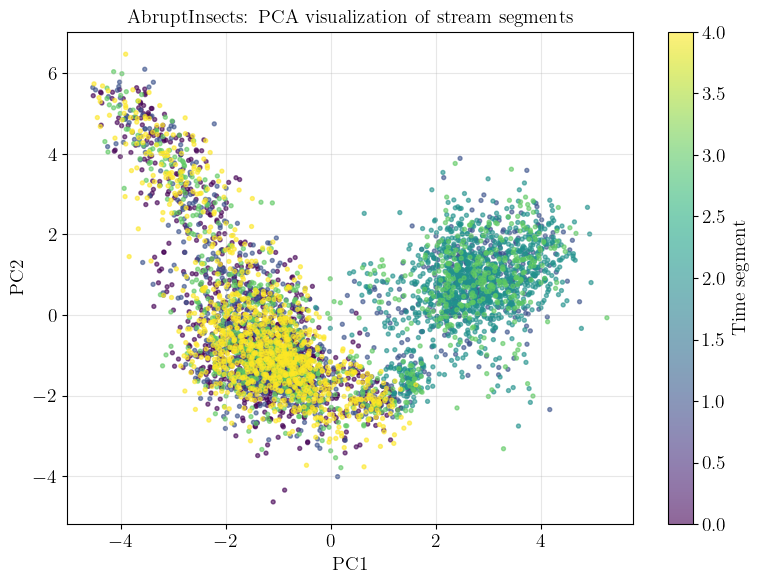

Explained variance ratio: [0.09538464 0.0633379 ]
Total explained variance: 0.1587225411703837


In [9]:
X_scaled = StandardScaler().fit_transform(X_vis)

pca = PCA(
    n_components=2,
    random_state=SEED,
)

X_pca = pca.fit_transform(X_scaled)

segment_size = len(X_vis) // 5

segments = np.minimum(
    np.arange(len(X_vis)) // segment_size,
    4,
)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=segments,
    s=8,
    alpha=0.6,
)

plt.title("AbruptInsects: PCA visualization of stream segments")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="Time segment")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

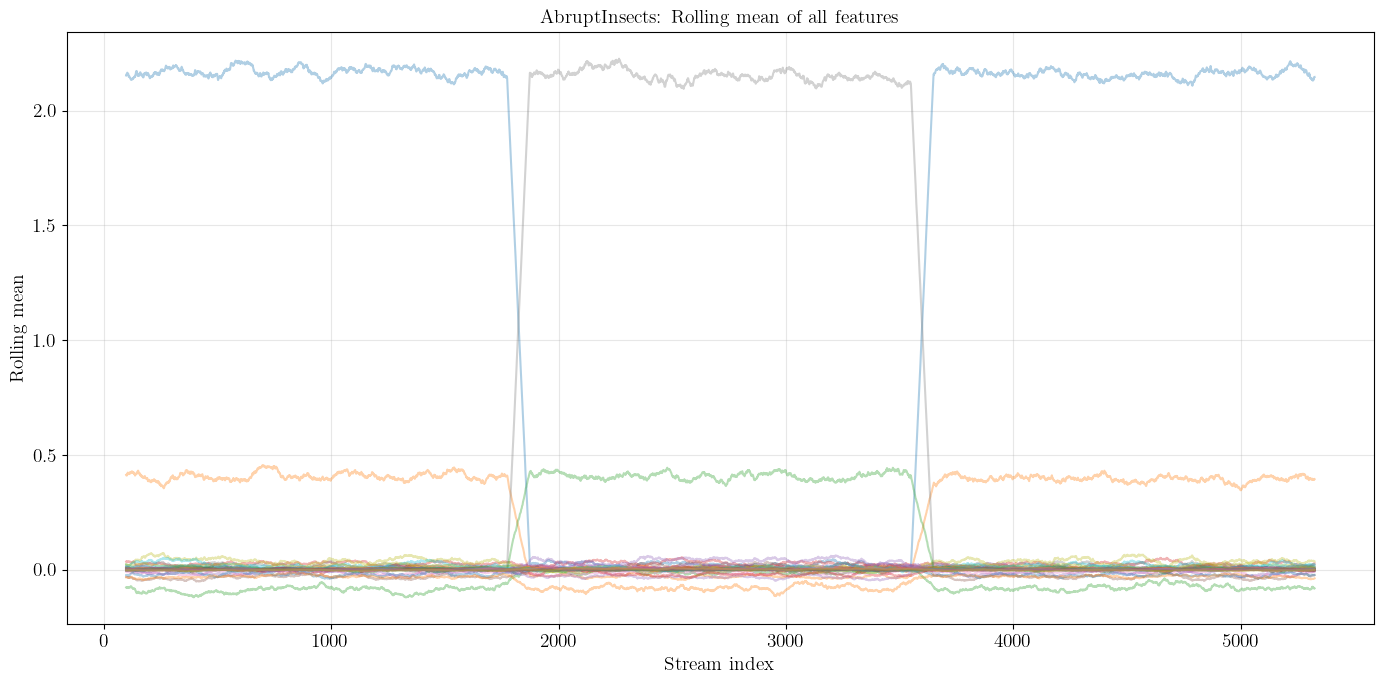

In [10]:
FEATURE_ROLLING_WINDOW = 100

X_df = pd.DataFrame(X_vis)

rolling_feature_means = (
    X_df
    .rolling(FEATURE_ROLLING_WINDOW)
    .mean()
)

plt.figure(figsize=(14, 7))

for feature in rolling_feature_means.columns:
    plt.plot(
        rolling_feature_means.index,
        rolling_feature_means[feature],
        linewidth=1.5,
        alpha=0.35,
    )


plt.title("AbruptInsects: Rolling mean of all features")
plt.xlabel("Stream index")
plt.ylabel("Rolling mean")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Run STUDD with each detector

Each STUDD detector is evaluated independently.

For each detector, we recreate the AbruptInsects stream, train the same teacher model, initialize the same student model and run STUDD.

The only changing component is the drift detector used inside STUDD.

For each detector, we store the teacher accuracy, the STUDD alarms and the teacher-student agreement signal monitored by STUDD.

In [11]:
comparison_runs = {}

for detector_name, detector_factory in DETECTORS.items():

    print(f"Running {detector_name}...")

    stream = NumpyStream(
        X,
        y,
        dataset_name="AbruptInsects",
    )

    schema = stream.get_schema()

    teacher = make_teacher(
        schema=schema,
        teacher_type=TEACHER_TYPE,
        seed=SEED,
        n_trees=N_TREES,
    )

    # Initial training window
    for _ in range(W):
        inst = stream.next_instance()
        teacher.train(inst)

    student = make_student(
        schema=schema,
        student_type=STUDENT_TYPE,
        seed=SEED,
        n_trees=N_TREES,
    )

    studd = STUDD(
        student=student,
        min_n_instances=W,
        detector=detector_factory(),
    )

    records = []
    studd_drift_points = []

    processed = W

    while stream.has_more_instances() and processed < N_STREAM:

        inst = stream.next_instance()

        y_true = inst.y_index
        y_teacher = teacher.predict(inst)

        if y_teacher is None:
            processed += 1
            continue

        teacher_correct = int(y_teacher == y_true)

        y_student = student.predict(inst)

        if y_student is None:
            agreement = np.nan
            disagreement = np.nan
        else:
            agreement = int(y_student == y_teacher)
            disagreement = 1 - agreement

        studd.add_element(
            inst,
            y_teacher,
        )

        detected_change = studd.detected_change()

        if detected_change:
            studd_drift_points.append(
                int(processed)
            )

        records.append({
            "t": int(processed),
            "teacher_correct": teacher_correct,
            "agreement": agreement,
            "disagreement": disagreement,
            "drift_alarm": detected_change,
        })

        processed += 1

    results = pd.DataFrame(records)

    agreement_idx = results["t"].to_numpy()

    agreement = results["agreement"].to_numpy(dtype=float)

    disagreement = results["disagreement"].to_numpy(dtype=float)

    first_alarm = (
        studd_drift_points[0]
        if studd_drift_points
        else None
    )

    closest_alarm = (
        min(
            studd_drift_points,
            key=lambda alarm: abs(alarm - reference_drift),
        )
        if studd_drift_points
        else None
    )

    closest_alarm_delay = (
        closest_alarm - reference_drift
        if closest_alarm is not None
        else None
    )

    false_alarms_before_reference = [
        alarm
        for alarm in studd_drift_points
        if alarm < reference_drift - MATCH_WINDOW
    ]

    candidate_detections = [
        alarm
        for alarm in studd_drift_points
        if alarm >= reference_drift - MATCH_WINDOW
    ]

    first_valid_alarm = (
        candidate_detections[0]
        if candidate_detections
        else None
    )

    first_valid_alarm_delay = (
        first_valid_alarm - reference_drift
        if first_valid_alarm is not None
        else None
    )

    # Metrics around the first SS alarm

    reference_before_disagreement = disagreement[
        (agreement_idx >= reference_drift - LOCAL_WINDOW)
        &
        (agreement_idx < reference_drift)
    ]

    reference_after_disagreement = disagreement[
        (agreement_idx >= reference_drift)
        &
        (agreement_idx < reference_drift + LOCAL_WINDOW)
    ]

    reference_before_accuracy = results[
        (results["t"] >= reference_drift - LOCAL_WINDOW)
        &
        (results["t"] < reference_drift)
    ]["teacher_correct"]

    reference_after_accuracy = results[
        (results["t"] >= reference_drift)
        &
        (results["t"] < reference_drift + LOCAL_WINDOW)
    ]["teacher_correct"]

    # Metrics around the closest STUDD alarm

    if closest_alarm is not None:

        closest_alarm_before_disagreement = disagreement[
            (agreement_idx >= closest_alarm - LOCAL_WINDOW)
            &
            (agreement_idx < closest_alarm)
        ]

        closest_alarm_after_disagreement = disagreement[
            (agreement_idx >= closest_alarm)
            &
            (agreement_idx < closest_alarm + LOCAL_WINDOW)
        ]

        closest_alarm_before_accuracy = results[
            (results["t"] >= closest_alarm - LOCAL_WINDOW)
            &
            (results["t"] < closest_alarm)
        ]["teacher_correct"]

        closest_alarm_after_accuracy = results[
            (results["t"] >= closest_alarm)
            &
            (results["t"] < closest_alarm + LOCAL_WINDOW)
        ]["teacher_correct"]

    else:

        closest_alarm_before_disagreement = np.array([])
        closest_alarm_after_disagreement = np.array([])

        closest_alarm_before_accuracy = pd.Series(dtype=float)
        closest_alarm_after_accuracy = pd.Series(dtype=float)

    summary = {
        "detector": detector_name,

        "num_alarms": len(studd_drift_points),
        "alarms": studd_drift_points,

        "num_false_alarms_before_reference": len(false_alarms_before_reference),
        "false_alarms_before_reference": false_alarms_before_reference,

        "first_alarm": first_alarm,

        "closest_alarm": closest_alarm,
        "closest_alarm_delay_from_ss": closest_alarm_delay,

        "first_valid_alarm": first_valid_alarm,
        "first_valid_alarm_delay_from_ss": first_valid_alarm_delay,

        "reference_accuracy_delta": (
            reference_after_accuracy.mean()
            - reference_before_accuracy.mean()
        ),

        "reference_disagreement_delta": (
            np.nanmean(reference_after_disagreement)
            - np.nanmean(reference_before_disagreement)
        ),

        "closest_alarm_accuracy_delta": (
            closest_alarm_after_accuracy.mean()
            - closest_alarm_before_accuracy.mean()
        ),

        "closest_alarm_disagreement_delta": (
            np.nanmean(closest_alarm_after_disagreement)
            - np.nanmean(closest_alarm_before_disagreement)
        ),
    }

    comparison_runs[detector_name] = {
        "summary": summary,
        "results": results,
        "agreement_idx": agreement_idx,
        "agreement": agreement,
        "disagreement": disagreement,
        "studd_drift_points": studd_drift_points,
    }

print("Done.")

Running ADWIN...


Running PageHinkley...
Running HDDMAverage...
Running HDDMWeighted...
Running CUSUM...
Done.


## Summary table

This table contains all metrics collected for each STUDD detector.

The main reference point is the first SS alarm.

For AbruptInsects, a useful STUDD detector should ideally:

- produce alarms reasonably close to the first SS alarm
- avoid excessive false alarms before the SS reference point
- show meaningful disagreement changes around either the SS reference point or the closest STUDD alarm

In [12]:
summary_df = pd.DataFrame([
    run["summary"]
    for run in comparison_runs.values()
])

summary_df = (
    summary_df
    .sort_values(
        "closest_alarm_delay_from_ss",
        key=lambda s: s.abs(),
        na_position="last",
    )
    .reset_index(drop=True)
)

summary_df

,detector,num_alarms,alarms,num_false_alarms_before_reference,false_alarms_before_reference,first_alarm,closest_alarm,closest_alarm_delay_from_ss,first_valid_alarm,first_valid_alarm_delay_from_ss,reference_accuracy_delta,reference_disagreement_delta,closest_alarm_accuracy_delta,closest_alarm_disagreement_delta
0,HDDMWeighted,1,[2575],0,[],2575,2575,662,2575,662,-0.079661,0.009195,0.078616,0.024929
1,ADWIN,3,"[3843, 4355, 5251]",0,[],3843,3843,1930,3843,1930,-0.079661,0.009195,-0.040000,0.040000
2,CUSUM,1,[4255],0,[],4255,4255,2342,4255,2342,-0.079661,0.009195,0.000000,-0.020000
3,HDDMAverage,1,[4469],0,[],4469,4469,2556,4469,2556,-0.079661,0.009195,0.040000,0.010000
4,PageHinkley,1,[5204],0,[],5204,5204,3291,5204,3291,-0.079661,0.009195,0.050000,0.020000


## Typical drift detection metrics

This section computes classic drift detection metrics using the first SS alarm as the reference drift point.

Following the STUDD paper, the first alarm triggered by SS is used as the concept drift occurrence.

Since this reference point is itself based on a detector, alarms that occur up to `W` observations before the first SS alarm are also considered true detections. This avoids penalizing detectors that react earlier than SS.

Therefore:

- alarms before `first SS alarm - W` are considered false alarms
- alarms from `first SS alarm - W` onward are considered true drift alarms
- if no such alarm exists, the detector is considered to have missed the drift

These metrics are computed per dataset and per detector. They can later be aggregated across datasets.

In [13]:
DATASET_NAME = "AbruptInsects"  

if len(ss_drift_points) == 0:
    raise ValueError(
        "SS did not trigger any alarm. "
        "This dataset cannot be used for SS-reference detection metrics."
    )

detection_metric_rows = []

valid_detection_start = reference_drift - W

for detector_name, run in comparison_runs.items():

    alarms = run["studd_drift_points"]

    false_alarms = [
        alarm
        for alarm in alarms
        if alarm < valid_detection_start
    ]

    true_drift_alarms = [
        alarm
        for alarm in alarms
        if alarm >= valid_detection_start
    ]

    if len(true_drift_alarms) == 0:

        missed_detection = 1
        first_true_detection = np.nan
        signed_detection_delay = np.nan
        detection_delay_for_mtd = np.nan
        normalized_detection_delay = np.nan

    else:

        missed_detection = 0

        # First alarm that qualifies as a true detection
        first_true_detection = int(min(true_drift_alarms))

        # Signed delay:
        # negative = detector alarmed before SS
        # positive = detector alarmed after SS
        signed_detection_delay = first_true_detection - reference_drift

        # For MTD, early detections are not penalized
        detection_delay_for_mtd = max(0, signed_detection_delay)

        normalized_detection_delay = (
            detection_delay_for_mtd / N_STREAM
        )

    has_false_alarm = int(len(false_alarms) > 0)

    if len(false_alarms) >= 2:

        false_alarm_intervals = np.diff(false_alarms)

        mean_time_between_false_alarms = float(
            np.mean(false_alarm_intervals)
        )

        normalized_mtfa = (
            mean_time_between_false_alarms / N_STREAM
        )

    else:

        mean_time_between_false_alarms = np.nan
        normalized_mtfa = np.nan

    detection_metric_rows.append({
        "dataset": DATASET_NAME,
        "detector": detector_name,

        "N_STREAM": N_STREAM,
        "W": W,
        "reference_drift": reference_drift,
        "valid_detection_start": valid_detection_start,

        "alarms": alarms,
        "num_alarms": len(alarms),

        "false_alarms": false_alarms,
        "num_false_alarms": len(false_alarms),
        "has_false_alarm": has_false_alarm,

        "true_drift_alarms": true_drift_alarms,
        "missed_detection": missed_detection,

        "first_true_detection": first_true_detection,
        "signed_detection_delay": signed_detection_delay,
        "detection_delay_for_mtd": detection_delay_for_mtd,
        "normalized_detection_delay": normalized_detection_delay,

        "mean_time_between_false_alarms": mean_time_between_false_alarms,
        "normalized_mtfa": normalized_mtfa,
    })

detection_metrics_df = pd.DataFrame(detection_metric_rows)

detection_metrics_df

,dataset,detector,N_STREAM,W,reference_drift,valid_detection_start,alarms,num_alarms,false_alarms,num_false_alarms,has_false_alarm,true_drift_alarms,missed_detection,first_true_detection,signed_detection_delay,detection_delay_for_mtd,normalized_detection_delay,mean_time_between_false_alarms,normalized_mtfa
0,AbruptInsects,ADWIN,5325,500,1913,1413,"[3843, 4355, 5251]",3,[],0,0,"[3843, 4355, 5251]",0,3843,1930,1930,0.362441,NaN,NaN
1,AbruptInsects,PageHinkley,5325,500,1913,1413,[5204],1,[],0,0,[5204],0,5204,3291,3291,0.618028,NaN,NaN
2,AbruptInsects,HDDMAverage,5325,500,1913,1413,[4469],1,[],0,0,[4469],0,4469,2556,2556,0.480000,NaN,NaN
3,AbruptInsects,HDDMWeighted,5325,500,1913,1413,[2575],1,[],0,0,[2575],0,2575,662,662,0.124319,NaN,NaN
4,AbruptInsects,CUSUM,5325,500,1913,1413,[4255],1,[],0,0,[4255],0,4255,2342,2342,0.439812,NaN,NaN


In [14]:
compact_detection_metrics_df = detection_metrics_df[
    [
        "dataset",
        "detector",
        "missed_detection",
        "has_false_alarm",
        "normalized_detection_delay",
        "normalized_mtfa",
        "num_alarms",
        "num_false_alarms",
    ]
].copy()

compact_detection_metrics_df

,dataset,detector,missed_detection,has_false_alarm,normalized_detection_delay,normalized_mtfa,num_alarms,num_false_alarms
0,AbruptInsects,ADWIN,0,0,0.362441,NaN,3,0
1,AbruptInsects,PageHinkley,0,0,0.618028,NaN,1,0
2,AbruptInsects,HDDMAverage,0,0,0.480000,NaN,1,0
3,AbruptInsects,HDDMWeighted,0,0,0.124319,NaN,1,0
4,AbruptInsects,CUSUM,0,0,0.439812,NaN,1,0


In [15]:
compact_detection_metrics_df.to_dict("records")

[{'dataset': 'AbruptInsects',
  'detector': 'ADWIN',
  'missed_detection': 0,
  'has_false_alarm': 0,
  'normalized_detection_delay': 0.3624413145539906,
  'normalized_mtfa': nan,
  'num_alarms': 3,
  'num_false_alarms': 0},
 {'dataset': 'AbruptInsects',
  'detector': 'PageHinkley',
  'missed_detection': 0,
  'has_false_alarm': 0,
  'normalized_detection_delay': 0.6180281690140845,
  'normalized_mtfa': nan,
  'num_alarms': 1,
  'num_false_alarms': 0},
 {'dataset': 'AbruptInsects',
  'detector': 'HDDMAverage',
  'missed_detection': 0,
  'has_false_alarm': 0,
  'normalized_detection_delay': 0.48,
  'normalized_mtfa': nan,
  'num_alarms': 1,
  'num_false_alarms': 0},
 {'dataset': 'AbruptInsects',
  'detector': 'HDDMWeighted',
  'missed_detection': 0,
  'has_false_alarm': 0,
  'normalized_detection_delay': 0.12431924882629108,
  'normalized_mtfa': nan,
  'num_alarms': 1,
  'num_false_alarms': 0},
 {'dataset': 'AbruptInsects',
  'detector': 'CUSUM',
  'missed_detection': 0,
  'has_false_ala

## Rolling teacher accuracy

The following plots show the rolling teacher accuracy for each detector run.

The first SS alarm is shown as a purple dashed line.

STUDD alarms are shown as red dotted lines.

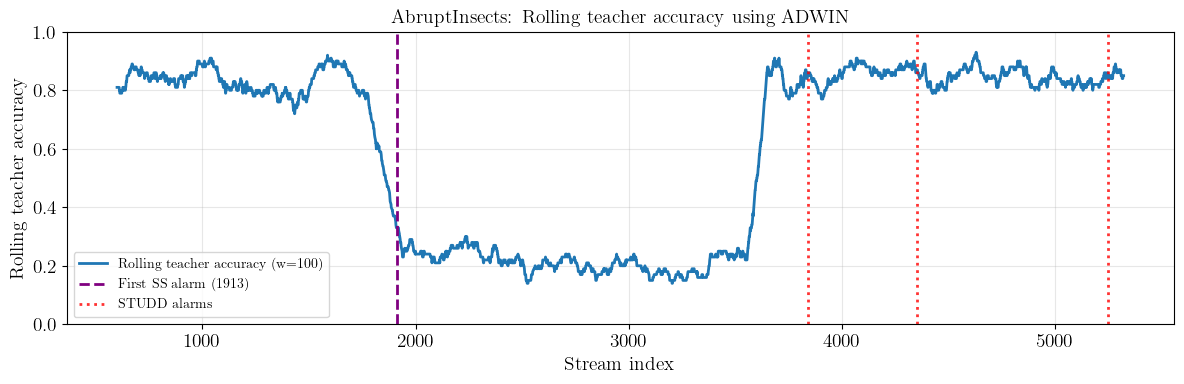

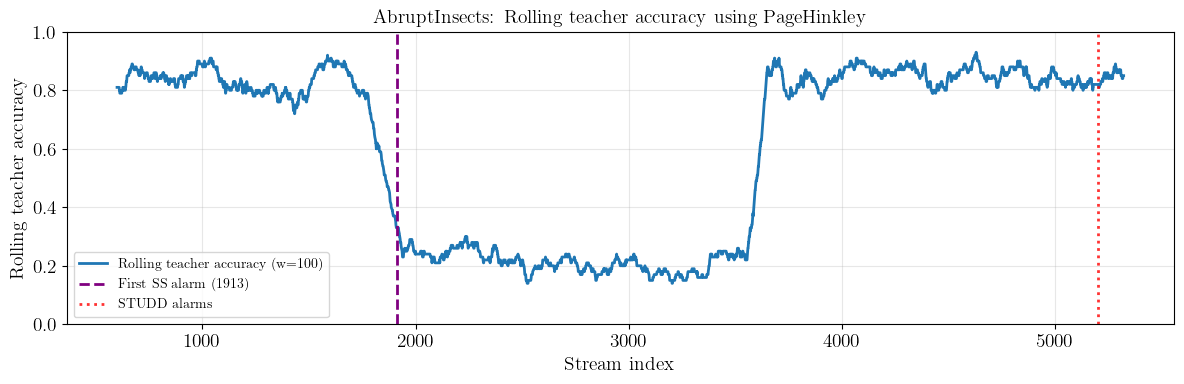

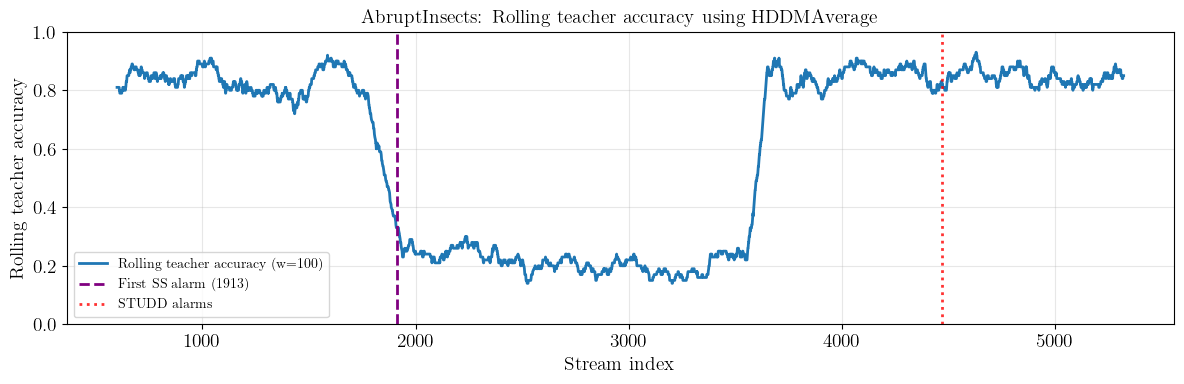

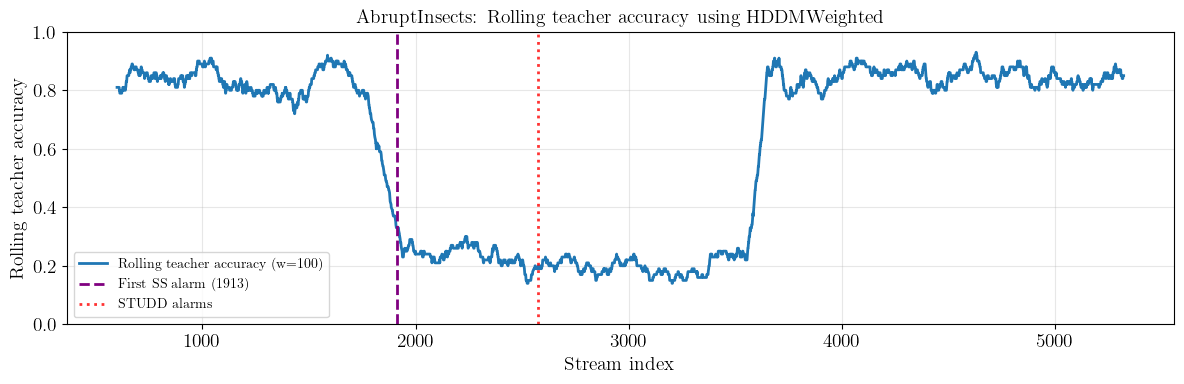

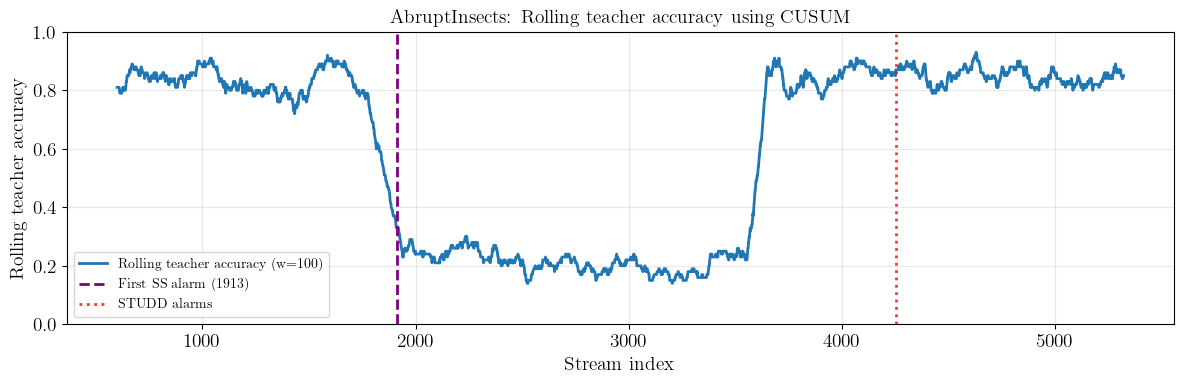

In [16]:
for detector_name, run in comparison_runs.items():

    results = run["results"]
    alarms = run["studd_drift_points"]

    rolling_accuracy, _ = rolling_mean(
        results["teacher_correct"].to_numpy(dtype=float),
        ROLLING_WINDOW,
    )

    rolling_t = results["t"].to_numpy()[
        ROLLING_WINDOW - 1:
    ]

    plt.figure(figsize=(12, 4))

    plt.plot(
        rolling_t,
        rolling_accuracy,
        linewidth=2,
        label=f"Rolling teacher accuracy (w={ROLLING_WINDOW})",
    )

    plt.axvline(
        reference_drift,
        color="purple",
        linestyle="--",
        linewidth=2,
        label=f"First SS alarm ({reference_drift})",
    )

    for i, alarm in enumerate(alarms):
        plt.axvline(
            alarm,
            color="red",
            linestyle=":",
            linewidth=2,
            alpha=0.8,
            label="STUDD alarms" if i == 0 else None,
        )

    plt.title(f"AbruptInsects: Rolling teacher accuracy using {detector_name}")
    plt.xlabel("Stream index")
    plt.ylabel("Rolling teacher accuracy")
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Rolling teacher-student disagreement

The following plots show the rolling teacher-student disagreement for each detector.

This is the signal monitored by STUDD.

The first SS alarm is shown as a purple dashed line.

STUDD alarms are shown as red dotted lines.

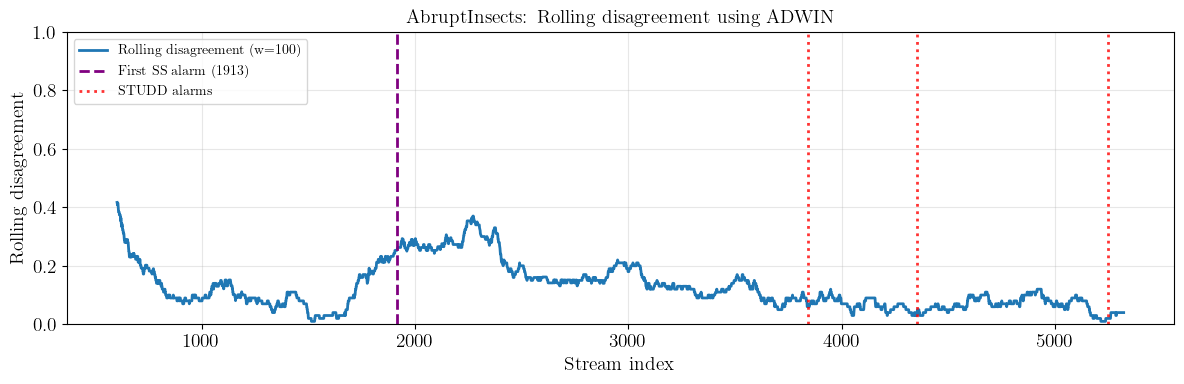

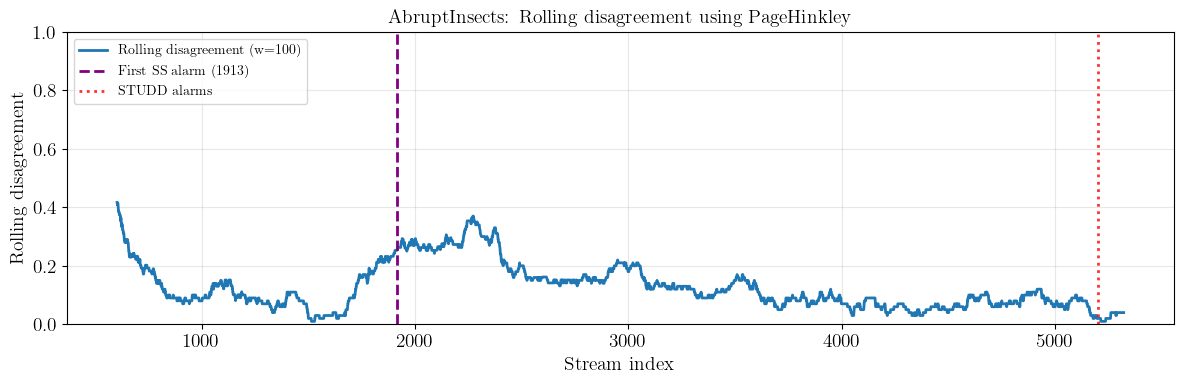

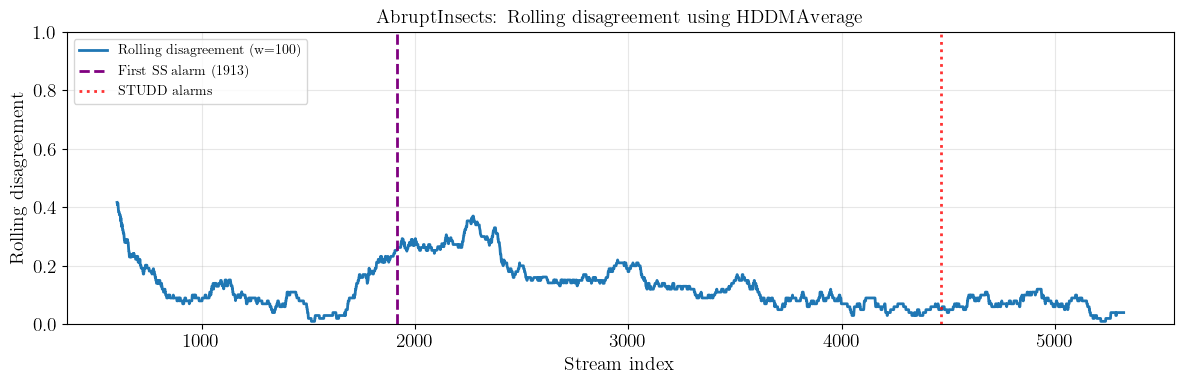

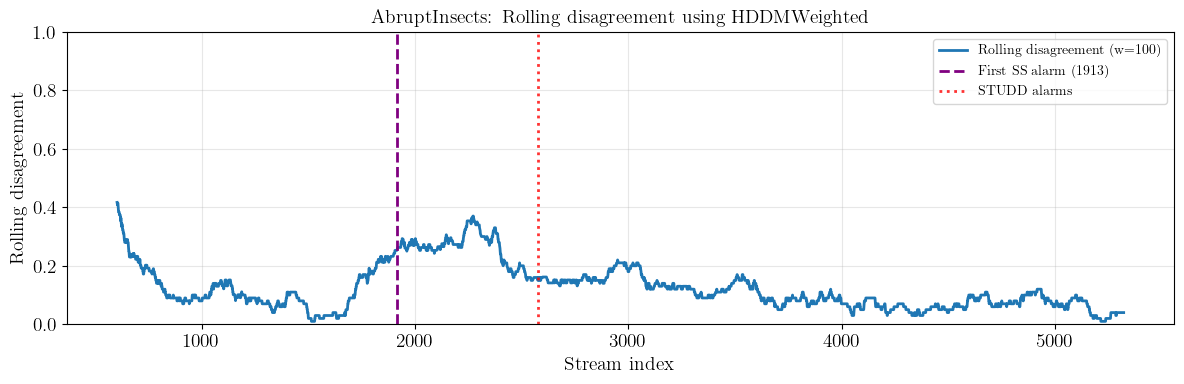

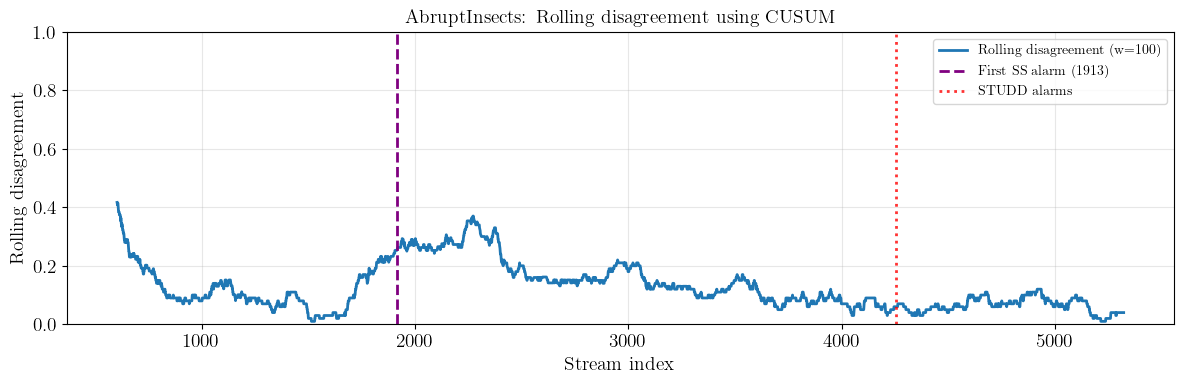

In [17]:
for detector_name, run in comparison_runs.items():

    results = run["results"]
    alarms = run["studd_drift_points"]

    rolling_disagreement = (
        results["disagreement"]
        .rolling(
            window=ROLLING_WINDOW,
            min_periods=1,
        )
        .mean()
    )

    rolling_t = results["t"]

    plot_mask = results["t"] >= W + ROLLING_WINDOW

    plt.figure(figsize=(12, 4))

    plt.plot(
        rolling_t[plot_mask],
        rolling_disagreement[plot_mask],
        linewidth=2,
        label=f"Rolling disagreement (w={ROLLING_WINDOW})",
    )

    plt.axvline(
        reference_drift,
        color="purple",
        linestyle="--",
        linewidth=2,
        label=f"First SS alarm ({reference_drift})",
    )

    for i, alarm in enumerate(alarms):
        plt.axvline(
            alarm,
            color="red",
            linestyle=":",
            linewidth=2,
            alpha=0.8,
            label="STUDD alarms" if i == 0 else None,
        )

    plt.title(f"AbruptInsects: Rolling disagreement using {detector_name}")
    plt.xlabel("Stream index")
    plt.ylabel("Rolling disagreement")
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Detector comparison summary

This notebook compares the effect of changing the detector inside STUDD on the AbruptInsects dataset.

To follow the paper's alarm-analysis, the first SS alarm is used as the reference drift indication.

All SS alarms are displayed in the plots for qualitative comparison, but only the first SS alarm is used as the reference point in the summary table.

The key quantities are:

- closest alarm delay from ss : how close the nearest STUDD alarm is to the first SS alarm
- number of false alarms before the reference : number of STUDD alarms occurring more than `W` observations before the first SS alarm
- number of alarms : total number of alarms produced by each detector
- reference accuracy delta : change in teacher accuracy around the first SS alarm
- reference disagreement delta : change in teacher-student disagreement around the first SS alarm
- closest alarm accuracy delta : change in teacher accuracy around the closest STUDD alarm
- closest alarm disagreement delta : change in teacher-student disagreement around the closest STUDD alarm